In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
import kagglehub
from pathlib import Path

download_dir = Path.cwd() / "data"
download_dir.mkdir(exist_ok=True)

dataset_file = download_dir / "AIML Dataset.csv"

# Download only if the file doesn't already exist
if not dataset_file.exists():
    print("Dataset not found. Downloading...")
    
    path = kagglehub.dataset_download(
        "amanalisiddiqui/fraud-detection-dataset",
        output_dir=str(download_dir)
    )
    
    print(f"Downloaded to: {path}")
else:
    print(f"Dataset already exists: {dataset_file}")

# Use the file
print(dataset_file)

Dataset already exists: c:\GH\ML\CreditCardFraudDetector\data\AIML Dataset.csv
c:\GH\ML\CreditCardFraudDetector\data\AIML Dataset.csv


In [3]:
csv_file = ".\data\AIML Dataset.csv"
# Load into DataFrame
raw_data = pd.read_csv(csv_file)

# Show first 5 rows
raw_data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


##EDA

In [4]:
raw_data.info()
raw_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

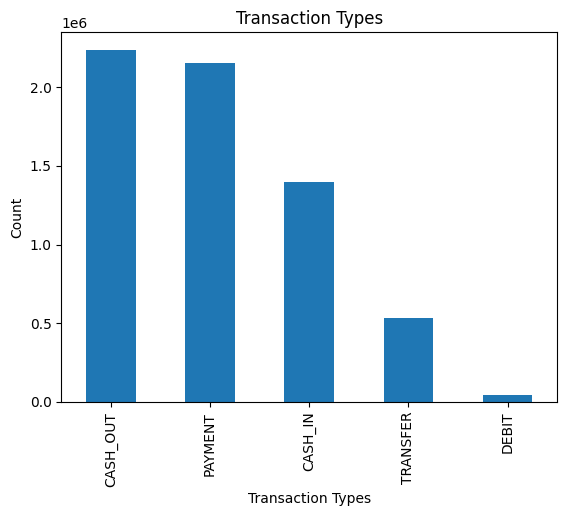

In [5]:
raw_data["type"].value_counts().plot(kind="bar", title = "Transaction Types")
plt.xlabel("Transaction Types")
plt.ylabel("Count")
plt.show()

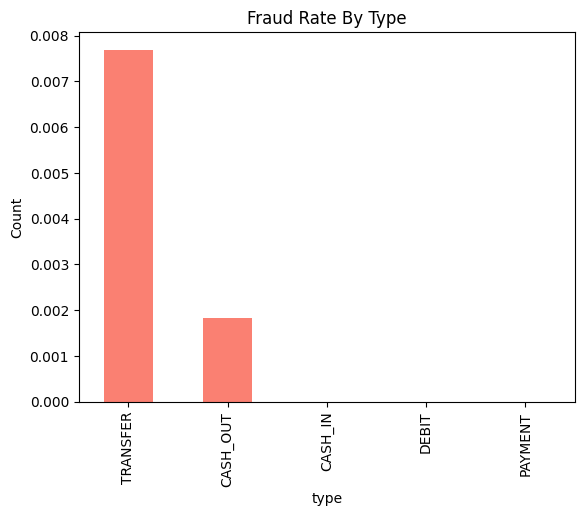

In [6]:
fraud_by_type = raw_data.groupby("type")["isFraud"].mean().sort_values(ascending = False)
fraud_by_type.plot(kind = "bar", title = "Fraud Rate By Type", color = "salmon")
plt.ylabel("Count")
plt.show()

In [7]:
raw_data.drop(columns="step", inplace=True)

##Feature Engineering and Model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [9]:
df_model = raw_data.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [10]:
X = df_model.drop(["isFraud"], axis = 1)
y = df_model["isFraud"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [12]:
#Split into numberical and categorical features
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()  
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [13]:
# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals 
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [14]:
#Combining the transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [15]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [16]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [17]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [18]:
confusion_matrix(y_test, y_pred)

array([[1802255,  104067],
       [    158,    2306]])

In [19]:
pipeline.score(X_test, y_test)*100

94.53972315387897

In [20]:
import joblib

joblib.dump(pipeline, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']